<a href="https://colab.research.google.com/github/Aaaaddddyyyyyyyy/Machine-Learning-repo/blob/main/bias_variace_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
X,y=make_circles(n_samples=500,factor=0.1,noise=35,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [4]:
X.shape

(500, 2)

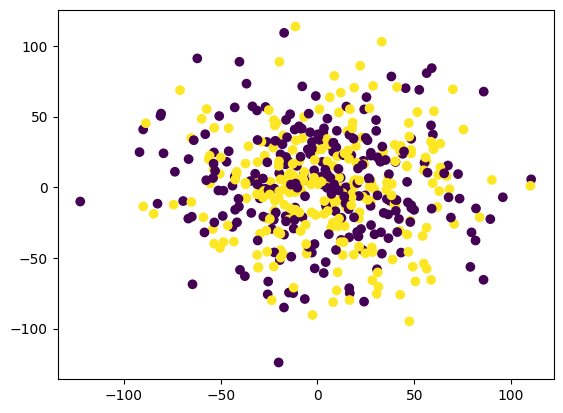

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
from sklearn.tree import DecisionTreeClassifier


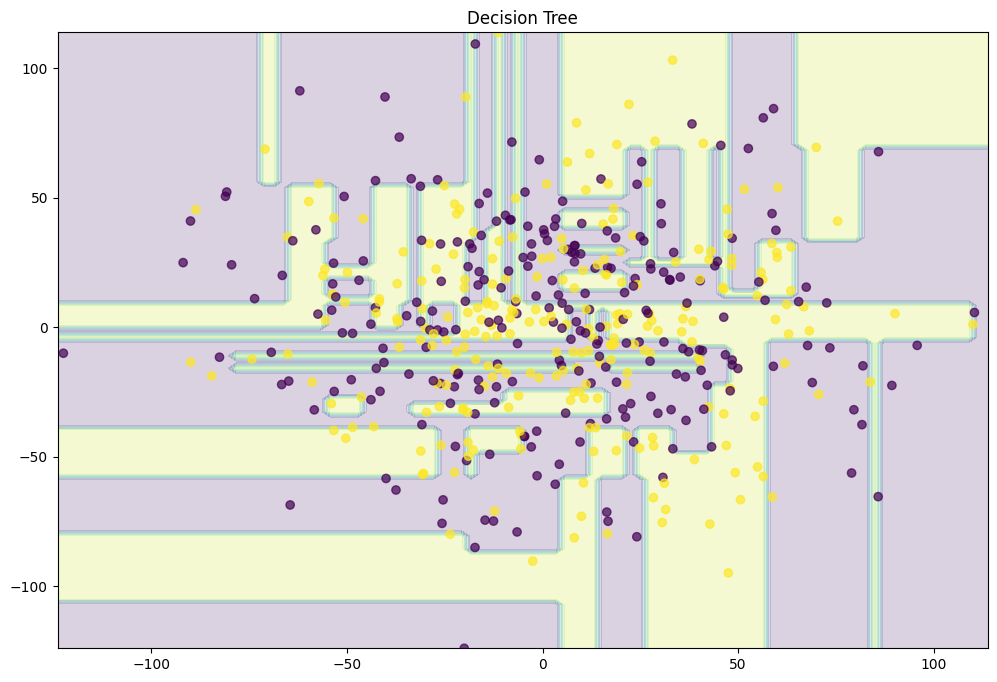

In [11]:
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
plt.figure(figsize=(12,8))
x_range= np.linspace(X.min(),X.max(),100)
xx1,xx2=np.meshgrid(x_range,x_range)
y_hat=dt.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat=y_hat.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_hat,alpha=0.2)
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis',alpha=0.7)
plt.title('Decision Tree')
plt.show()

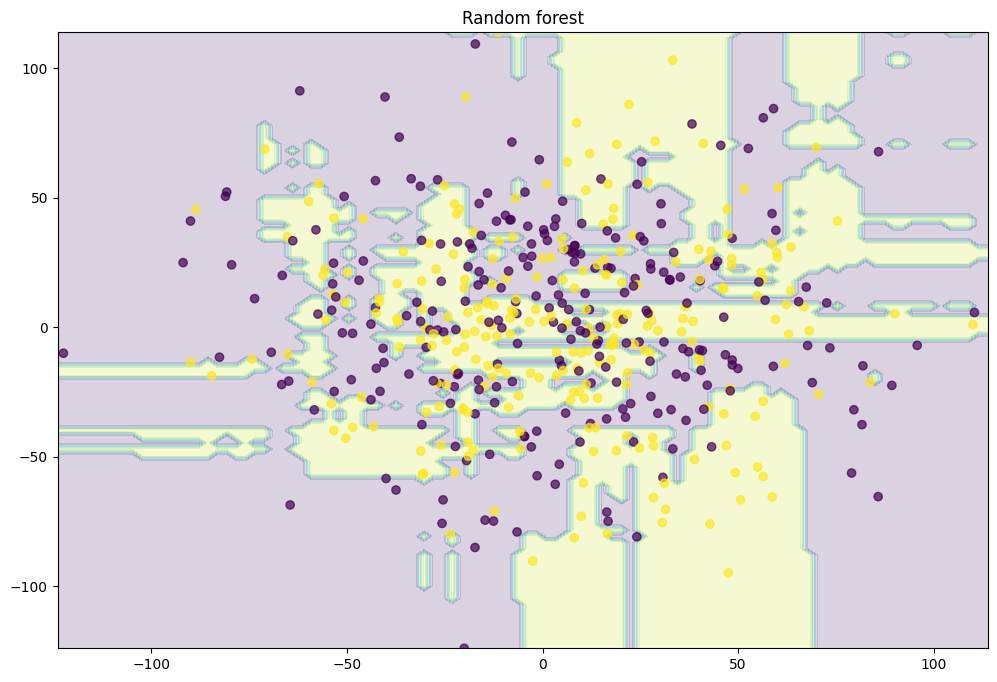

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=500,random_state=42)
rf.fit(X_train,y_train)

plt.figure(figsize=(12,8))
x_range=np.linspace(X.min(),X.max(),100)
xx1,xx2 = np.meshgrid(x_range,x_range)
y_hat=rf.predict(np.c_[xx1.ravel(),xx2.ravel()])
y_hat=y_hat.reshape(xx1.shape)
plt.contourf(xx1,xx2,y_hat,alpha=0.2)
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis',alpha=0.7)
plt.title('Random forest')
plt.show(mb)

In [13]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [14]:
X,y=make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)

In [15]:
df=pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])         # target is outout column
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-2.127303,0.894951,-0.600518,-1.191874,-1.573884,0
1,1.358732,-0.317099,-1.022977,-0.844633,-1.257109,1
2,-0.357856,-0.732070,1.007794,0.276790,-2.545119,0
3,-0.908792,0.922910,2.763722,1.154730,-0.059090,0
4,-1.616429,0.557361,-2.640315,-3.413477,-2.837048,0


In [16]:
bag=BaggingClassifier(max_features=2)

In [17]:
bag.fit(df.iloc[:,:5],df.iloc[:,-1])


BaggingClassifier(max_features=2)

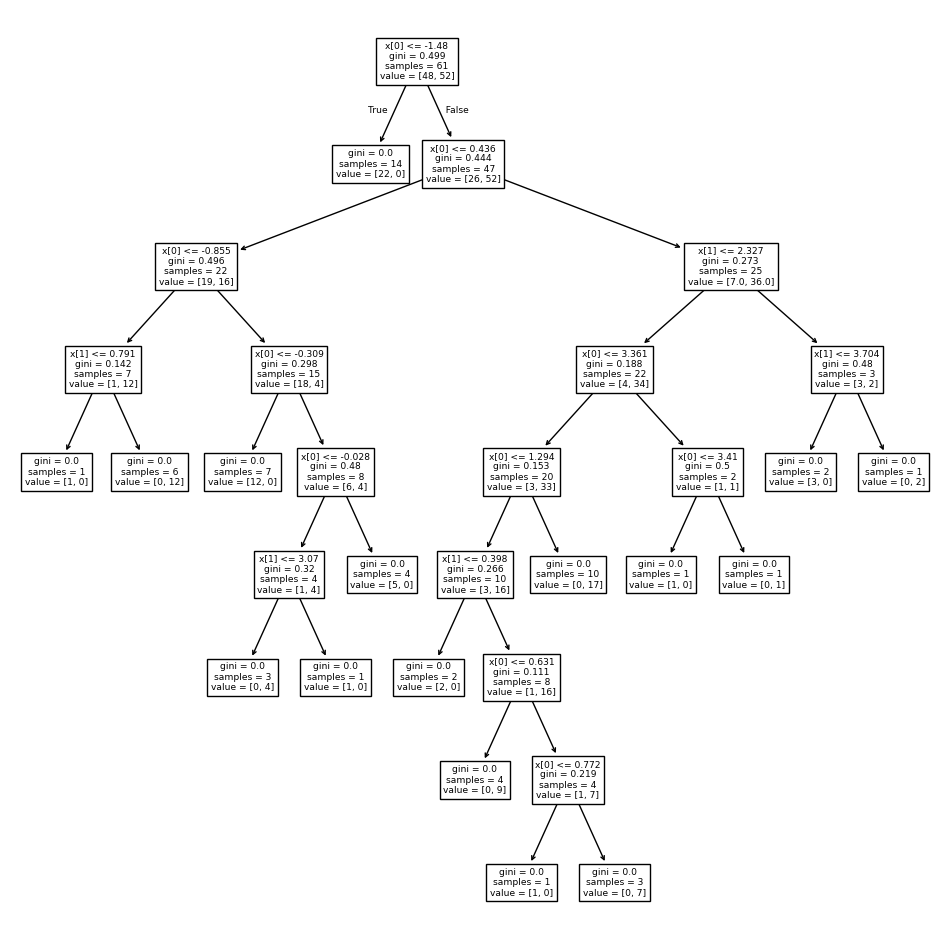

In [19]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

In [20]:
rf=RandomForestClassifier()

In [21]:
rf.fit(df.iloc[:,:5],df.iloc[:,-1])

RandomForestClassifier()

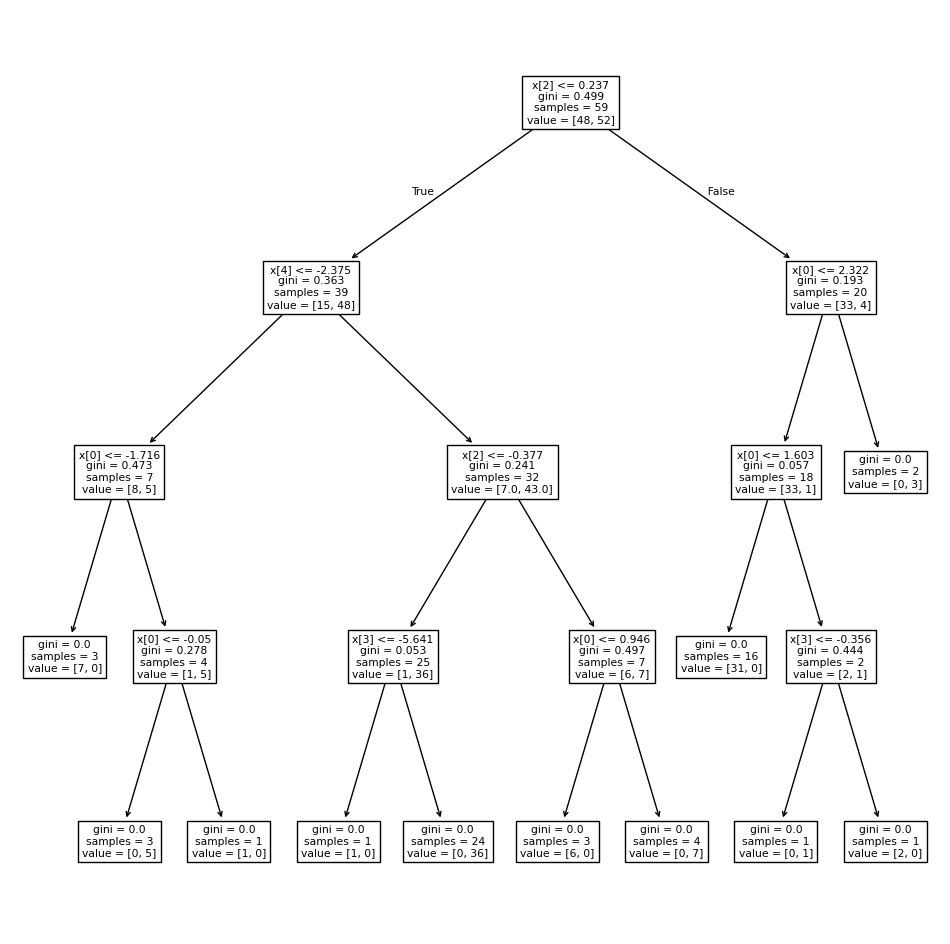

In [22]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[0])
plt.show()